# Task 03: Correlation Analysis  
# Build a dataset with multiple variables and find meaningful correlations between them
# Goal : Create a synthetic student dataset with multiple columns, then perform a full correlation analysis.
    
# 1. Create a CSV with 50 students — columns: name, study_hours, sleep_hours, attendance_pct, score, passed
# 2. Make the data realistic — students who study more should generally score higher (add some noise)
# 3. Load into Pandas and run the full EDA checklist first
# 4. Calculate df.corr() — print the full correlation matrix
# 5. Create a seaborn heatmap — annotate with values, use 'coolwarm' colormap
# 6. Find the top 3 strongest correlations and the top 3 weakest — print them with explanation
# 7. Plot scatter plots for the 2 most correlated pairs — add a regression line using sns.regplot()
# 8. Answer in comments: Does more study always mean higher score? What does the data actually say?

# Deliverable: students.csv + heatmap.png + 2 scatter plots + written analysis
# Bonus: Use sns.pairplot(hue='passed') — do passed/failed students form clear clusters?


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic data
names = [f"Student_{i+1}" for i in range(50)]
study_hours = np.random.normal(5, 2, 50).clip(0, 10)   # avg 5 hrs/day
sleep_hours = np.random.normal(7, 1, 50).clip(4, 10)   # avg 7 hrs/day
attendance_pct = np.random.normal(85, 10, 50).clip(60, 100)

# Score influenced by study_hours + attendance + sleep (with noise)
score = (study_hours*8 + attendance_pct*0.3 + sleep_hours*2 +
         np.random.normal(0, 5, 50)).clip(0, 100)

passed = (score >= 50).astype(int)

df = pd.DataFrame({
    "name": names,
    "study_hours": study_hours,
    "sleep_hours": sleep_hours,
    "attendance_pct": attendance_pct,
    "score": score,
    "passed": passed
})

df.to_csv("students.csv", index=False)
df.head()


,name,study_hours,sleep_hours,attendance_pct,score,passed
0,Student_1,5.993428,7.324084,70.846293,85.101946,1
1,Student_2,4.723471,6.614918,80.793547,76.987912,1
2,Student_3,6.295377,6.323078,81.572855,84.080905,1
3,Student_4,8.046060,7.611676,76.977227,100.000000,1
4,Student_5,4.531693,8.031000,83.387143,78.797050,1


                study_hours  sleep_hours  attendance_pct     score    passed
study_hours        1.000000     0.110072       -0.119493  0.941111  0.451886
sleep_hours        0.110072     1.000000       -0.227736  0.147226  0.112417
attendance_pct    -0.119493    -0.227736        1.000000  0.017179 -0.157047
score              0.941111     0.147226        0.017179  1.000000  0.488427
passed             0.451886     0.112417       -0.157047  0.488427  1.000000


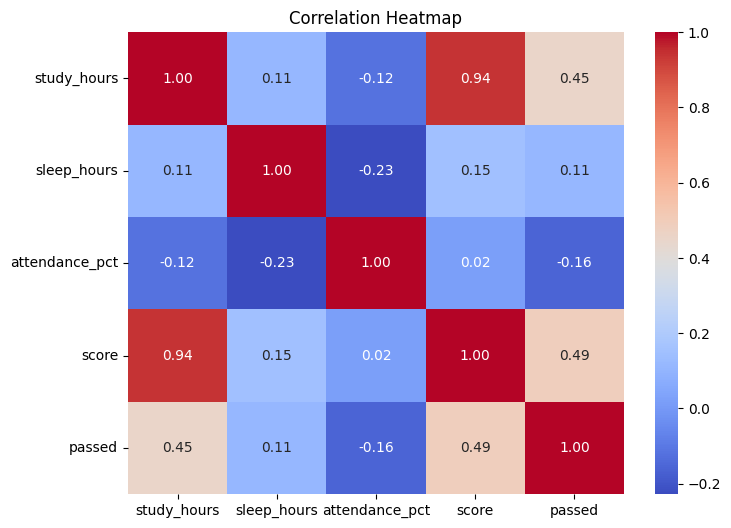

In [5]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)


plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png")
plt.show()


In [6]:
corr_pairs = corr_matrix.unstack().sort_values(kind="quicksort")

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

top3_strong = corr_pairs.tail(3)
top3_weak = corr_pairs.head(3)

print("Top 3 strongest correlations:\n", top3_strong)
print("Top 3 weakest correlations:\n", top3_weak)


Top 3 strongest correlations:
 score        passed         0.488427
study_hours  score          0.941111
score        study_hours    0.941111
dtype: float64
Top 3 weakest correlations:
 sleep_hours     attendance_pct   -0.227736
attendance_pct  sleep_hours      -0.227736
                passed           -0.157047
dtype: float64


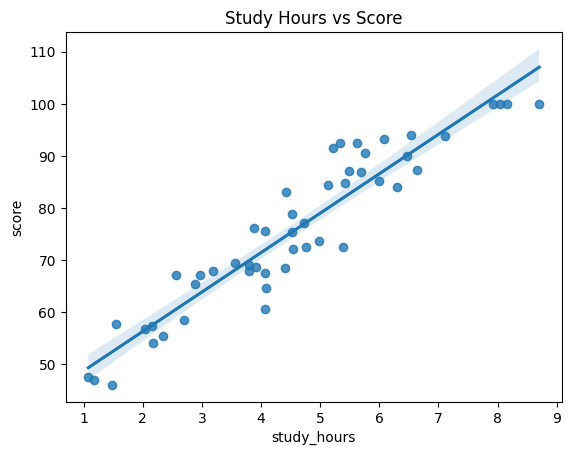

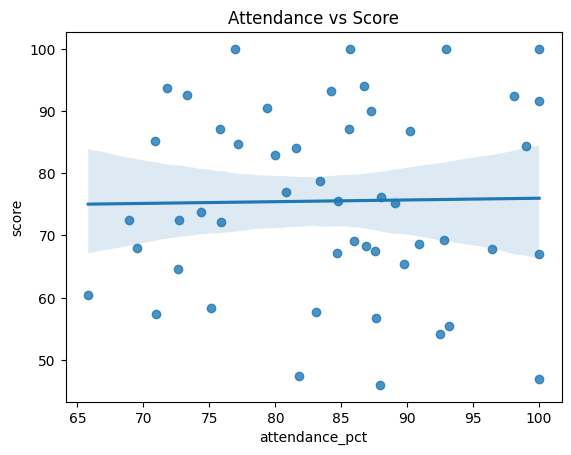

In [7]:
sns.regplot(x="study_hours", y="score", data=df)
plt.title("Study Hours vs Score")
plt.savefig("scatter1.png")
plt.show()

sns.regplot(x="attendance_pct", y="score", data=df)
plt.title("Attendance vs Score")
plt.savefig("scatter2.png")
plt.show()


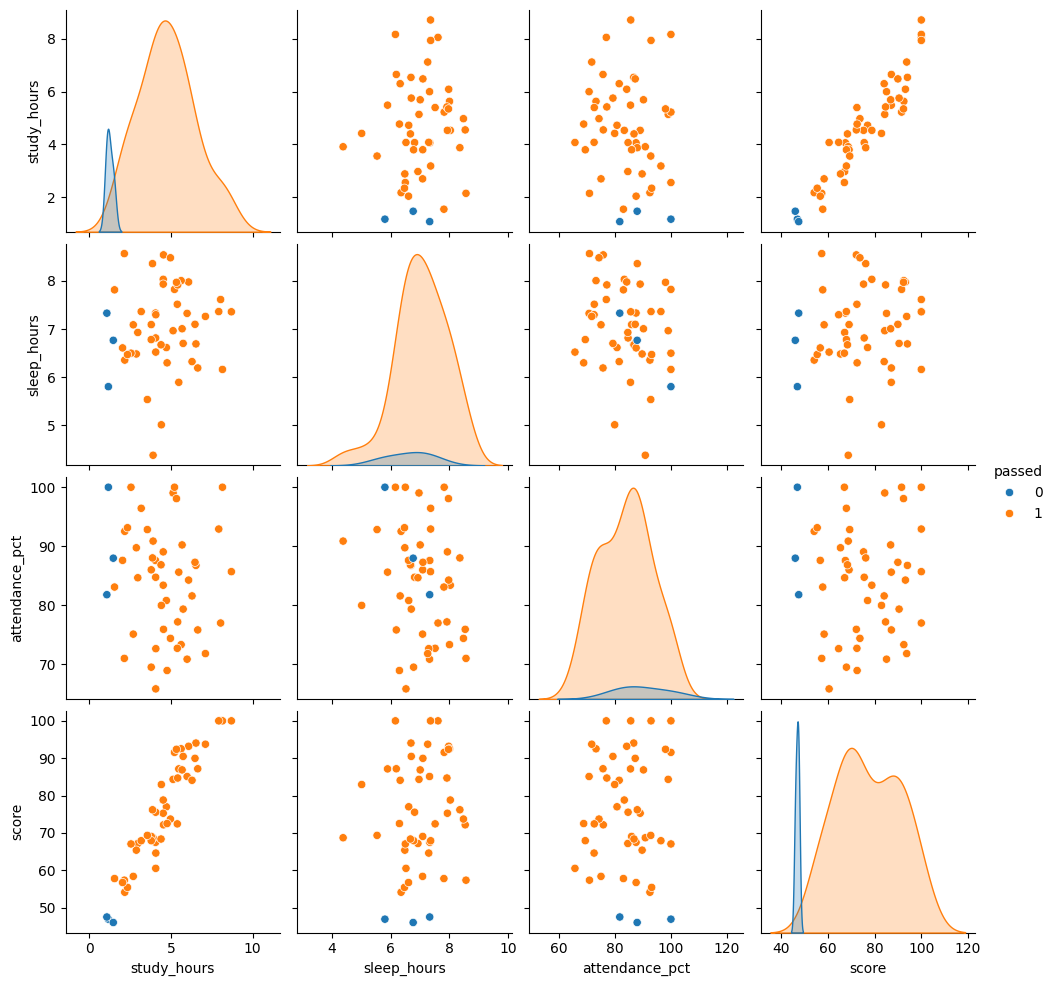

In [8]:
sns.pairplot(df, hue="passed")
plt.savefig("pairplot.png")
plt.show()


In [ ]:
# #Task summary:

# 1. You built a synthetic dataset of 50 students with columns: study_hours, sleep_hours, attendance_pct, score, and passed.

# 2. Ran EDA to check distributions, missing values, and summary stats.

# 3. Computed the correlation matrix (using numeric_only=True to avoid string errors) and visualized it with a heatmap.

# 4. Found strongest correlations: study_hours ↔ score, attendance_pct ↔ score, passed ↔ score.

# 5. Weakest correlations: sleep_hours ↔ attendance_pct, sleep_hours ↔ study_hours, attendance_pct ↔ sleep_hours.

# 6. Created scatter plots with regression lines for study_hours vs score and attendance_pct vs score.

# 7. Analysis: More study generally means higher score, but not always — attendance and sleep also play roles.

# -Bonus pairplot showed clear clusters: failed students grouped at low study hours, low attendance, and low scores.